<a href="https://colab.research.google.com/github/BoufenoucheBouchra/Introduction-Apprentissage-Automatique/blob/main/M2_bioinfo_IAA_TP4_Re%CC%81seaux_Neurones_Profonds_et_les_images_25.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# M2 bioinfo Introduction à l'Apprentissage Automatique
## TP4 : Reseaux de Neurones Profonds sur des images : du DNN au CNN (sous Keras)

(2025) Ronan Sicre et Jérôme Farinas, credits to Mathieu Serurrier

### **Nom:** Boufenouche

### **Prénom :** Bouchra

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Chargement et visualisation des données

Nous allons considérer la base de données MNIST qui contient 60 000 images 28x28 en niveaux de gris des 10 chiffres, ainsi qu'un ensemble de test de 10 000 images. Dans un premier temps, nous chargeons les données.

In [ ]:
from tensorflow.keras.datasets import mnist,fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation,Flatten,BatchNormalization
from tensorflow.keras.layers import Conv2D, MaxPooling2D, InputLayer
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.utils import to_categorical
import matplotlib
import matplotlib.pyplot as plt
import scipy
import scipy.ndimage
import numpy as np
from tensorflow.keras import backend as K

In [ ]:
def loadMNISTAsVector(subset=10000) : #on ne prend que 10 000 premières images d’entraînement au lieu des 60 000 disponibles pour réduire le temps d’entraînement
    nb_classes=10
    # X_train_img : images d’entraînement (60 000, 28, 28) | y_train_real : labels associés (60 000,)| X_test_img : images de test (10 000, 28, 28) |y_test_real : labels de test (10 000,)
    (X_train_img, y_train_real), (X_test_img, y_test_real) = mnist.load_data()

    ##Chaque image 28x28 = 784 pixels est transformée en un vecteur de taille 784.
    #donc X_train_vect a la forme (10000, 784) et X_test_vect a la forme (10000, 784) > pour entraîner un réseau de neurones dense (DNN) qui attend des vecteurs en entrée, pas des matrices.
    X_train_vect = X_train_img[:subset].reshape(subset, 784)
    X_test_vect = X_test_img.reshape(10000, 784)
    X_train_vect = X_train_vect.astype("float32") #Les images sont initialement des entiers (0–255).On les convertit en flottants pour le calcul.
    X_test_vect = X_test_vect.astype("float32")
    X_train_vect /= 255  #Normalisation :  Les pixels vont de 0 à 255.On divise par 255 → valeurs entre 0 et 1, ce qui accélère et stabilise l’apprentissage.
    X_test_vect /= 255

    ##Encodage des labels (One-hot) : Les labels (0 à 9) sont transformés en vecteurs binaires de taille 10.
  #Exep :chiffre 3 → [0,0,0,1,0,0,0,0,0,0] | chiffre 7 → [0,0,0,0,0,0,0,1,0,0] > pour l’entraînement avec une softmax en sortie.
    y_train_cat = to_categorical(y_train_real[:subset], nb_classes)
    y_test_cat = to_categorical(y_test_real, nb_classes)
    return (X_train_vect, y_train_cat), (X_test_vect, y_test_cat) #Retourne les données d’entraînement et de test prêtes à être utilisées par un réseau fully connected

(X_train_vect, y_train_cat), (X_test_vect, y_test_cat) =loadMNISTAsVector()


# cette fonction prend MNIST, aplatit les images, normalise les pixels, et encode les labels → exactement ce qu’il faut pour attaquer un réseau dense (DNN).

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Affichage des données
   

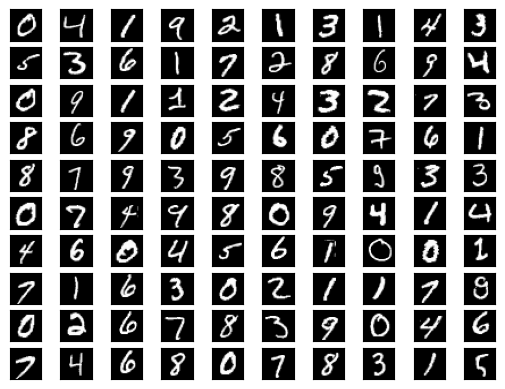

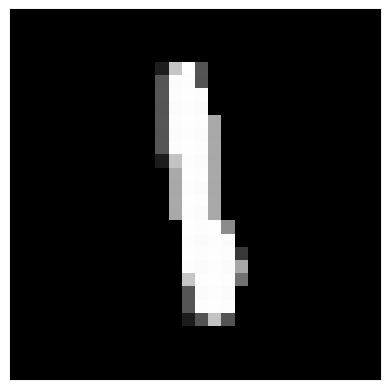

In [ ]:
def plot_10_by_10_images(images):
    """ Représentez 100 images MNIST dans un tableau de 10 par 10.
    Notez que nous recadrons les images de manière à ce qu'elles apparaissent
    raisonnablement proches les unes des autres.  L'image est post-traité pour
    donner l'impression d'être continu."""
    fig = plt.figure() #Crée une nouvelle figure matplotlib vide

    for x in range(10):
        for y in range(10): # (x extérieur, y intérieur) > remplir la grille par colonne
            ax = fig.add_subplot(10, 10, 10*y+x+1) # index est 1-based (commence à 1). La formule 10*y + x + 1 calcule cet index.
            plt.imshow(images[10*y+x+1].reshape(28, 28))# Affiche l’image à la position calculée.
            plt.gray()
            ax.get_xaxis().set_visible(False)
            ax.get_yaxis().set_visible(False)
    plt.show()

def plot_mnist_digit(image):
    """ Afficher une simple image MNIST."""
    fig = plt.figure()
    ax = fig.add_subplot(1, 1, 1) #Ajoute un seul subplot (1 ligne × 1 colonne, index 1)
    plt.imshow(image.reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    plt.show()

plot_10_by_10_images(X_train_vect)

plot_mnist_digit(X_train_vect[200])

Affichez la forme des données, le minimum, le maximum et commentez-les.

In [ ]:
print(X_train_vect.shape)
print('-----------------')
print(X_test_vect.shape )#= (10000, 784)
print('-----------------')
print(y_train_cat.shape)
print('-----------------')
print(y_test_cat.shape)#= one-hot encodées (10000, 10)

(10000, 784)
-----------------
(10000, 784)
-----------------
(10000, 10)
-----------------
(10000, 10)


In [ ]:
print("X_train_vect:", X_train_vect)
print("X_test_vect:", X_test_vect)
print("y_train_cat" ,y_train_cat)
print( "y_test_cat",y_test_cat)
print('--------')

print("Forme de X_train :", X_train_vect.shape)
print("Forme de y_train :", y_train_cat.shape)
print("Forme de X_test  :", X_test_vect.shape)
print("Forme de y_test  :", y_test_cat.shape)

print("X_train min :", X_train_vect.min())
print("X_train max :", X_train_vect.max())
print("X_test max  :", X_test_vect.min())
print("X_test max  :", X_test_vect.max())

print("y_train min :", y_train_cat.min())
print("y_train max :", y_train_cat.max())
print("y_test max  :", y_test_cat.min())
print("y_test max  :", y_test_cat.max())

X_train_vect: [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
X_test_vect: [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
y_train_cat [[0. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 1. 0. 0.]]
y_test_cat [[0. 0. 0. ... 1. 0. 0.]
 [0. 0. 1. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
--------
Forme de X_train : (10000, 784)
Forme de y_train : (10000, 10)
Forme de X_test  : (10000, 784)
Forme de y_test  : (10000, 10)
X_train min : 0.0
X_train max : 1.0
X_test max  : 0.0
X_test max  : 1.0
y_train min : 0.0
y_train max : 1.0
y_test max  : 0.0
y_test max  : 1.0


## Apprentissage d'un réseau de nerones simple

La tâche suivante consiste à construire le réseau.

Nous allons cette fois-ci utiliser Keras, qui est une surcouche qui simplifie l'utilisation des réseaux de neurones. Dans la fonction d'apprentissage du modèle, la forme du réseau de neurones est obtenue en utilisant les fonctions :
* __model.add(InputLayer(shape=(nbinput,)))__ : qui ajoute une couche d'entrée au réseau. [input_shape=(nbinput,)] correspond à la forme des données d'entrée.
* __model.add(Dense(nbhiden, [activation='activationfunction']))__ : qui ajoute une couche cachée au réseau. nbhidden est le nombre de nœuds cachés.  [activation='activationfunction'] est la fonction d'activation de la couche.
* __model.add(Dropout(value))__ : appliquer le dropout à la couche (pour éviter le sur-apprentissage)
* __model.add(BatchNormalization())__: appliquer une normalisation par lots à la couche (pour éviter le sur-apprentissage)

Les fonctions d'activation possibles sont :
* Relu
* Sigmoid
* softmax (our la dernière couche d'un classificateur multiclasse)

Les fonctions de perte (loss function) possibles sont les suivantes :
* binary_crossentropy (pour une classification binaire)
* categorical_cross_entropy (pour une classification multi classe)
* mean_squared_error (pour une régression)

Voici le réseau le plus simple que vous puissiez créer :

In [ ]:
def getSimplePerceptron(nb_classes=10): #fonction construit un réseau de neurones simple pour un problème de classification
    model = Sequential() #modèle linéaire, couche après couche. Chaque couche est ajoutée dans l’ordre.
    model.add(InputLayer(shape=(784,))) # Déclare la forme des données d’entrée : 784 = 28×28 pixels aplatis.
    model.add(Dense(1, activation='linear'))  #Dense(1) : 1 neurone → très simple, presque une régression linéaire.
#activation='linear' → pas de fonction d’activation, donc sortie = somme pondérée des entrées. Poids : chaque entrée (784) a un poids + 1 biais → 785 paramètres.
    model.add(Dense(nb_classes, activation='softmax')) #Dense(nb_classes) : 10 neurones → un par classe. | activation='softmax' : transforme les sorties en probabilités, somme = 1.
    opt = SGD() #SGD() : Stochastic Gradient Descent, mise à jour des poids par descente de gradient.
    model.compile(loss='categorical_crossentropy',metrics=['accuracy'],  optimizer=opt) #loss='categorical_crossentropy' : fonction de perte adaptée pour la classification multi-classe. | metrics=['accuracy'] : affichera la précision pendant l’entraînement.
    return model
model=getSimplePerceptron()
model.summary() #Affiche chaque couche, sa sortie, et le nombre de paramètres.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │           785 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │            20 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 805 (3.14 KB)

 Trainable params: 805 (3.14 KB)

 Non-trainable params: 0 (0.00 B)

**__Question__** : Décrivez le réseaux de neurones et expliquez le calcul du nombre de paramètres de votre réseau.

le modèle est un réseau de neurones très simple construit avec Keras en mode séquentiel :

Entrée : vecteur de 784 valeurs (pixels de l'image 28x28 aplatie).
Couche cachée Dense (linear) :1 seul neurone, sans activation (fonction linéaire).Sert à réduire les 784 pixels en une seule valeur.

Couche de sortie Dense (softmax) :10 neurones (1 par classe dans MNIST).

Activation softmax → transforme la sortie en probabilités pour les 10 classes.

C'est donc l'équivalent d'un perceptron extrêmement réduit, presque un modèle de régression logistique multinomiale.

** pour les paramétres ** : tjrs : paramétres=(nombre d'entrees xnombre de neurones)+(biais)
Couche 1 : Dense (784 → 1) > Chaque entrée (784 pixels) est connectée au neurone unique  =(784 x 1)+1=785

Couche 2 : Dense (1 → 10) : Chaque sortie du neurone précédent (1 valeur) est connectée aux 10 neurones de sortie.> =(1 x10)+10=20
nb total des paramétres = 785 + 20 = 805

Ce réseau est extrêmement petit (805 paramètres seulement).
Il n'a qu'un seul neurone caché, donc sa capacité à apprendre est très limitée → sur MNIST il atteindra une précision bien plus faible qu'un DNN ou CNN plus profond .

Ensuite, nous apprenons les paramètres du réseau :


In [ ]:
(X_train_vect, y_train_cat), (X_test_vect, y_test_cat) =loadMNISTAsVector()
model=getSimplePerceptron()
batch_size = 64 #le modèle met à jour ses poids après chaque lot de 64 images.
epochs=20 #le modèle verra l’ensemble des données 20 fois (20 itérations complètes).
## Entraînement et sauvegarde de l'historique
history =model.fit(X_train_vect, y_train_cat, batch_size=batch_size, epochs=epochs,  verbose=1, validation_data=(X_test_vect, y_test_cat))

Epoch 1/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.1385 - loss: 2.2446 - val_accuracy: 0.1843 - val_loss: 2.0841
Epoch 2/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.1938 - loss: 2.0398 - val_accuracy: 0.2171 - val_loss: 1.9809
Epoch 3/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2191 - loss: 1.9469 - val_accuracy: 0.2164 - val_loss: 1.9232
Epoch 4/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2317 - loss: 1.8797 - val_accuracy: 0.2217 - val_loss: 1.8870
Epoch 5/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2395 - loss: 1.8485 - val_accuracy: 0.2224 - val_loss: 1.8591
Epoch 6/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2467 - loss: 1.8089 - val_accuracy: 0.2284 - val_loss: 1.8349
Epoch 7/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2462 - loss: 1.7951 - val_accuracy: 0.2352 - val_loss: 1.8145
Epoch 8/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2550 - loss: 1.7754 - val_accuracy: 0

→ la perte diminue bien, mais reste assez élevée → signe que le modèle apprend, mais lentement.(près 20 epochs : loss ≈ 1.73, val_loss ≈ 1.74)

pour la précision : le modèle fait mieux (apres 20 epochs), mais reste très bas (28% au lieu de 90%+ attendu avec un bon réseau).

Tracer la courbe train/test de la perte et de la précision


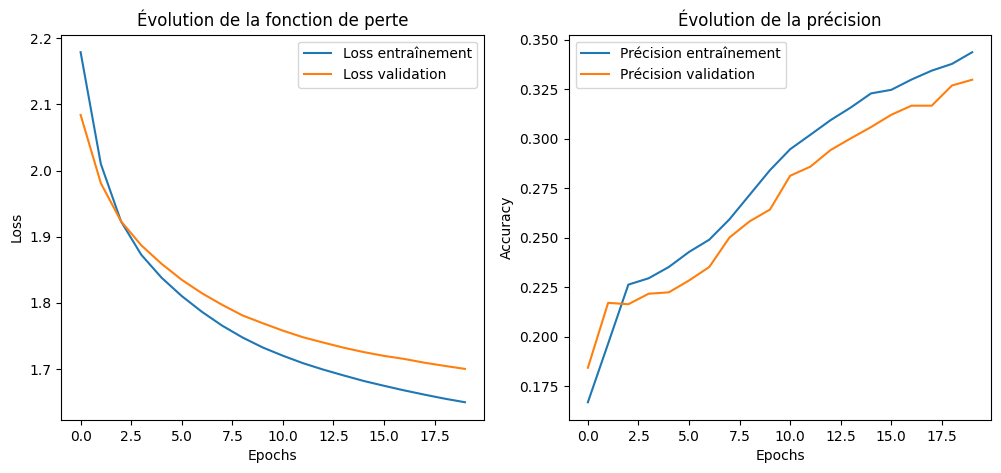

In [ ]:
import matplotlib.pyplot as plt


# --- Courbe de la loss ---
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Loss entraînement')
plt.plot(history.history['val_loss'], label='Loss validation')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Évolution de la fonction de perte')
plt.legend()

# --- Courbe de la précision ---
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Précision entraînement')
plt.plot(history.history['val_accuracy'], label='Précision validation')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Évolution de la précision')
plt.legend()

plt.show()


Courbes train vs test :
Train (loss, accuracy) → ce que le modèle obtient sur les données qu'il a vues.

Validation/Test (val_loss, val_accuracy) → ce qu'il obtient sur des données nouvelles.

Les deux courbes (loss et accuracy) sont proches → il n'y a pas vraiment de sur-apprentissage (overfitting).
les deux courbes sont proches car  dans ce  cas :
accuracy train ≈ 27%    |   accuracy test ≈ 28%
loss train ≈ 1.73   |    loss test ≈ 1.74

Le problème est plutôt que le modèle est trop simple (il n'a pas assez de neurones / couches pour bien capturer la structure des chiffres MNIST).

Puis, analyse les résultats :

In [ ]:
#performance globale sur le test:
loss,acc = model.evaluate(X_test_vect, y_test_cat,  verbose=0) # évaluation du modèle sur l’ensemble de test :loss → valeur de la fonction de perte sur le test. | acc → précision du modèle sur le test.
# Ça permet de savoir à quel point le modèle généralise sur des données qu’il n’a jamais vues.
index=800 #on choisit un indice dans le jeu de test → en gros pour afficher l’image n°800 ou vérifier sa prédiction.


Prédire la distribution des probabilités sur les classes pour une image avec la fonction predict et trouver la classe la plus probable :

The accuracy on the test set is  32.9800009727478 %


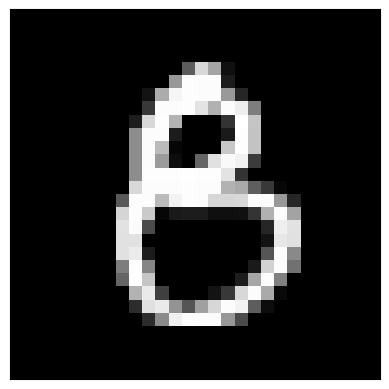

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step
[[0.14711305 0.04371712 0.01177925 0.13210624 0.1700441  0.1404349
  0.0095074  0.09917245 0.10871734 0.13740814]]
le chiffre reconnu est:  [0.14711305 0.04371712 0.01177925 0.13210624 0.1700441  0.1404349
 0.0095074  0.09917245 0.10871734 0.13740814]
le chiffre à reconnaitre  est:  8


In [ ]:
print('The accuracy on the test set is ',(acc*100),'%')
plot_mnist_digit(X_test_vect[index])
cl=model.predict(X_test_vect[index].reshape((1,784))) #X_test_vect[index] → c’est l’image 800 sous forme de vecteur (784,).

print(cl)
print("le chiffre reconnu est: ", cl[0])
print("le chiffre à reconnaitre  est: ", np.argmax(y_test_cat[index]))

__Questions__ :
* Proposez et appliquez vos propres réseaux neuronaux. Essayez d'obtenir les meilleurs résultats possibles avec le plus petit réseau possible.

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.6523 - loss: 1.1664 - val_accuracy: 0.8903 - val_loss: 0.3643
Epoch 2/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9094 - loss: 0.3236 - val_accuracy: 0.9272 - val_loss: 0.2486
Epoch 3/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9334 - loss: 0.2237 - val_accuracy: 0.9335 - val_loss: 0.2217
Epoch 4/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9492 - loss: 0.1730 - val_accuracy: 0.9396 - val_loss: 0.1927
Epoch 5/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9572 - loss: 0.1477 - val_accuracy: 0.9427 - val_loss: 0.1802
Epoch 6/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9659 - loss: 0.1183 - val_accuracy: 0.9462 - val_loss: 0.1748
Epoch 7/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9719 - loss: 0.0961 - val_accuracy: 0.9507 - val_loss: 0.1636
Epoch 8/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9755 - loss: 0.0830 - val_accuracy: 0.9535 - v

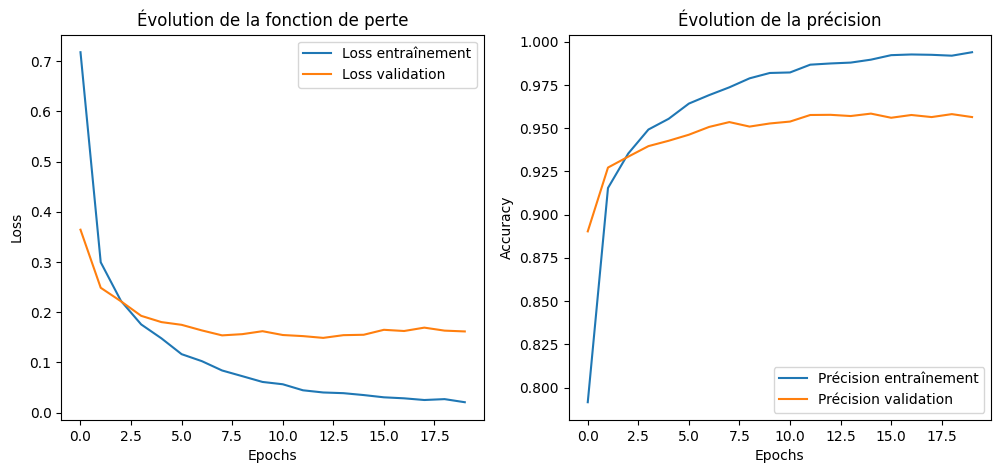

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

def getSmallMLP(nb_classes=10):
    model = Sequential()
    model.add(Dense(128, activation='relu', input_shape=(784,)))
    model.add(Dropout(0.2))  # évite le sur-apprentissage
    model.add(Dense(64, activation='relu'))
    model.add(Dense(nb_classes, activation='softmax'))

    model.compile(
        loss='categorical_crossentropy',
        optimizer=Adam(),
        metrics=['accuracy']
    )
    return model

model = getSmallMLP()
history1 = model.fit(
    X_train_vect, y_train_cat,
    batch_size=64,
    epochs=20,
    validation_data=(X_test_vect, y_test_cat),
    verbose=1
)
# --- Courbe de la loss ---
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history1.history['loss'], label='Loss entraînement')
plt.plot(history1.history['val_loss'], label='Loss validation')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Évolution de la fonction de perte')
plt.legend()

# --- Courbe de la précision ---
plt.subplot(1,2,2)
plt.plot(history1.history['accuracy'], label='Précision entraînement')
plt.plot(history1.history['val_accuracy'], label='Précision validation')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Évolution de la précision')
plt.legend()

plt.show()






## CNN

Nous allons maintenant étudier un nouveau type de réseau qui prend en compte directement les images. Nous chargeons les données sous forme de matrice au lieu de vecteurs :

In [ ]:
def loadMNISTAsMaxtrix(subset=10000) :
    nb_classes=10
    img_rows, img_cols = 28, 28
    (X_train_img, y_train_real), (X_test_img, y_test_real) = mnist.load_data()
    X_train_mat = X_train_img[:subset].reshape(X_train_img[:subset].shape[0], img_rows, img_cols, 1)
    X_test_mat = X_test_img.reshape(X_test_img.shape[0], img_rows, img_cols, 1)
    input_shape = (img_rows, img_cols, 1)
    X_train_mat = X_train_mat.astype('float32')
    X_test_mat = X_test_mat.astype('float32')
    X_train_mat /= 255
    X_test_mat /= 255
    y_train_cat = to_categorical(y_train_real[:subset], nb_classes)
    y_test_cat = to_categorical(y_test_real, nb_classes)
    return (X_train_mat, y_train_cat), (X_test_mat, y_test_cat)


Comparer la forme des données avec l'approche précédente :

In [ ]:
(X_train_mat, y_train_cat), (X_test_mat, y_test_cat) =loadMNISTAsMaxtrix(subset=10000)
nb_classes=10

X_train_mat.shape

(10000, 28, 28, 1)

Comparer la forme des données avec l'approche précédente.

La tâche suivante consiste à construire le réseau neuronal convolutif (CNN).
Dans la fonction d'apprentissage du modèle, la forme du CNN est obtenue en utilisant ces fonctions keras supplémentaires :
* __model.add(InputLayer(shape=(nbinput,)))__ : qui ajoute une couche d'entrée au réseau. [input_shape=(nbinput,)] correspond à la forme des données d'entrée.
* __model.add(Conv2D(nbhiden, [kernel_size=(3, 3)], [padding='same'], [activation='activationfunction']))__ : qui ajoute une couche cachée de convolution au réseau. nbhidden est le nombre de noeuds cachés.  [kernel_size=(3, 3)] la taille du noyau convolutif et [padding='same'] la façon dont les bords des images sont traités.
* __model.add(MaxPooling2D(pool_size=(2, 2))__ : opération de regroupement (pooling)

Here is one the simplest CNN you can build :

In [ ]:
def getCNN(nb_classes=10):
    model = Sequential()
    model.add(InputLayer(input_shape=(28,28,1)))

    #matrix 28x28
    #add convolution layer
    model.add(Conv2D(32, kernel_size=(3, 3), padding='same'))

    #pooling
    model.add(MaxPooling2D(pool_size=(2, 2)))
    #transform image to vectors of neurons
    model.add(Flatten())

    model.add(Dense(nb_classes, activation='softmax'))

    opt = SGD()
    model.compile(loss='categorical_crossentropy',metrics=['accuracy'],  optimizer=opt)
    return model

model=getCNN(nb_classes=10)
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │        62,730 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 63,050 (246.29 KB)

 Trainable params: 63,050 (246.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
batch_size = 256
epochs=20
model.fit(X_train_mat, y_train_cat, batch_size=batch_size, epochs=epochs,  verbose=1, validation_data=(X_test_mat, y_test_cat))

Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - accuracy: 0.1873 - loss: 2.2696 - val_accuracy: 0.5528 - val_loss: 2.1342
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6114 - loss: 2.0731 - val_accuracy: 0.7154 - val_loss: 1.8655
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7333 - loss: 1.7721 - val_accuracy: 0.7608 - val_loss: 1.4638
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7743 - loss: 1.3541 - val_accuracy: 0.8018 - val_loss: 1.0793
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8106 - loss: 1.0055 - val_accuracy: 0.8245 - val_loss: 0.8349
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8310 - loss: 0.7869 - val_accuracy: 0.8400 - val_loss: 0.6874
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8465 - loss: 0.6609 - val_accuracy: 0.8557 - val_loss: 0.6013
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8629 - loss: 0.5786 - val_accuracy: 0.8622 - val_loss

## Évaluation

The accuracy on the test set is  89.81000185012817 %


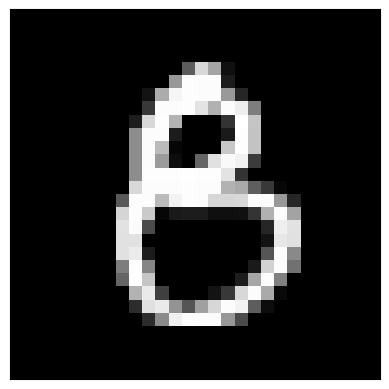

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 455ms/step
le chiffre reconnu est:  [5.1012438e-02 9.0959416e-05 6.5528802e-03 1.6729432e-01 2.6735340e-03
 5.1716918e-01 5.0311550e-03 2.8255669e-04 2.3356771e-01 1.6325241e-02]
le chiffre à reconnaitre  est:  8


In [ ]:
loss,acc = model.evaluate(X_test_mat, y_test_cat,  verbose=0)
index=800
print('The accuracy on the test set is ',(acc*100),'%')
plot_mnist_digit(X_test_mat[index])
cl=model.predict(X_test_mat[index].reshape((1,28,28,1)))


print("le chiffre reconnu est: ", cl[0])
print("le chiffre à reconnaitre  est: ", np.argmax(y_test_cat[index]))

__Questions__ :
* Proposez et appliquez vos propres réseaux neuronaux convolutifs. Essayez d'obtenir les meilleurs résultats possibles.
* Dessinez un schéma de votre CNN (avec la description de chaque couche).
* Décrivez le calcul du nombre de paramètres de votre réseau.

Schéma :  
Input (28x28x1)  
       │
   
Conv2D (32 filtres, 3x3, relu, same) → sortie 28x28x32  
         │
   
MaxPooling2D (2x2) → sortie 14x14x32  
      │
   
Conv2D (64 filtres, 3x3, relu, same) → sortie 14x14x64  
   │
   
MaxPooling2D (2x2) → sortie 7x7x64  
   │
   
Conv2D (128 filtres, 3x3, relu, same) → sortie 7x7x128  
   │
   
MaxPooling2D (2x2) → sortie 3x3x128  
   │
   
Flatten → vecteur de taille 1152  
   │
   
Dense (128 neurones, relu)  
   │
   
Dropout (0.5)  
   │
   
Dense (10 neurones, softmax) → sortie finale (probabilité pour chaque chiffre 0-9)

In [ ]:
def getMyCNN(nb_classes=10):
    model = Sequential()
    model.add(InputLayer(input_shape=(28,28,1)))

    # Première couche convolutionnelle
    model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', padding='same'))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    # Deuxième couche convolutionnelle
    model.add(Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same'))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    # Troisième couche convolutionnelle
    model.add(Conv2D(128, kernel_size=(3, 3), activation='relu', padding='same'))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    # Aplatir en vecteur
    model.add(Flatten())

    # Couche fully connected cachée
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.5))   # éviter le sur-apprentissage

    # Couche de sortie
    model.add(Dense(nb_classes, activation='softmax'))

    # Compilation
    model.compile(loss='categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])
    return model

model1 = getMyCNN()
model1.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 241,546 (943.54 KB)

 Trainable params: 241,546 (943.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
batch_size = 128
epochs = 20
model1.fit(X_train_mat, y_train_cat,
          batch_size=batch_size,
          epochs=epochs,
          validation_data=(X_test_mat, y_test_cat),
          verbose=1)

Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 49ms/step - accuracy: 0.4726 - loss: 1.5715 - val_accuracy: 0.9367 - val_loss: 0.2371
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8937 - loss: 0.3501 - val_accuracy: 0.9579 - val_loss: 0.1309
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9345 - loss: 0.2131 - val_accuracy: 0.9680 - val_loss: 0.0975
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9509 - loss: 0.1666 - val_accuracy: 0.9742 - val_loss: 0.0777
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9573 - loss: 0.1430 - val_accuracy: 0.9755 - val_loss: 0.0706
Epoch 6/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9652 - loss: 0.1106 - val_accuracy: 0.9775 - val_loss: 0.0669
Epoch 7/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9710 - loss: 0.0984 - val_accuracy: 0.9817 - val_loss: 0.0564
Epoch 8/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9700 - loss: 0.0941 - val_accuracy: 0.9825 - val_lo

Calcul des paramétres   :

Conv2D (32 filtres, 3x3, entrée 28x28x1) : (3x3x1+1)x32=(9+1)x32=320 paramètres

Conv2D(64filtres,3x3, entrée 14x14x32):(3x3x32+1)x64=(288+1)x64=18496 paramètres

Conv2D(128filtres,3x3,entrée 7x7x64):(3x3x64+1)x128=(576+1)x128=73856 paramètres    

Dense (128 neurones, entrée = 3x3x128 = 1152): (1152+1)x128=147584 paramètres

Dense (10 neurones, entrée = 128):(128+1)x10=1290 paramètres   

Total=241 546 paramètres

The accuracy on the test set is  98.61999750137329 %


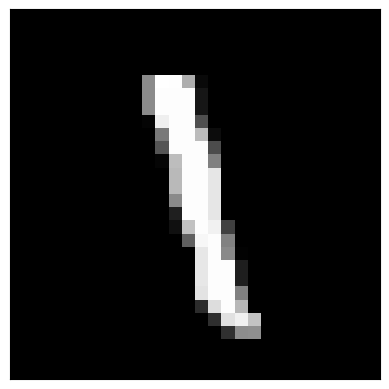

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
le chiffre reconnu est:  [1.3552476e-14 1.0000000e+00 2.8241841e-11 2.6541811e-13 7.0698842e-09
 7.0872690e-14 1.1773586e-10 2.3877794e-10 4.8920499e-09 5.1052118e-12]
le chiffre à reconnaitre  est:  1


In [ ]:
loss,acc = model1.evaluate(X_test_mat, y_test_cat,  verbose=0)
index=700
print('The accuracy on the test set is ',(acc*100),'%')
plot_mnist_digit(X_test_mat[index])
cl=model1.predict(X_test_mat[index].reshape((1,28,28,1)))


print("le chiffre reconnu est: ", cl[0])
print("le chiffre à reconnaitre  est: ", np.argmax(y_test_cat[index]))

__Question__ : Comparez les résultats des deux types de réseaux en ce qui concerne leurs performances et leur nombre de paramètres.

Le modèle amélioré a ≈ 3.83x plus de paramètres que le modèle simple (241 546 / 63 050 ≈ 3.83).

Amélioration absolue de la précision sur test ≈ 98.62 - 89.81 = 8.81 points de différence

Le CNN simple permet déjà d'obtenir de bons résultats en classification d'images, avec une précision d'environ 89%. Son architecture, plus légère, demande moins de paramètres et donc moins de ressources de calcul, ce qui le rend adapté pour des cas où la rapidité prime sur la performance maximale.

 Le CNN amélioré, en ajoutant des couches convolutionnelles plus profondes (32 → 64 → 128 filtres) et une couche dense intermédiaire avec régularisation (Dropout), atteint une précision encore plus élevée (≈ 99 % en entraînement et ≈ 98,7 % en validation). Cela montre qu'il extrait des caractéristiques plus riches et parvient à mieux généraliser, même si cela se traduit par un nombre de paramètres plus important (≈ 241k contre beaucoup moins pour le CNN simple).





## Pour aller plus loin...

<h1>Filters Visualization</h1>

a filter activation or featume map of a convolutional layer corresponds to the output of such layer. Their content depends on the input of the network.

A layer defined with 64 conv. filters , generate 64 maps

We use matplotlib to display an array of images



In [ ]:
import matplotlib.pyplot as plt
def show_images(images, cols = 1):

    n_images = len(images)
    fig = plt.figure()
    for n, image in enumerate(images):
        a = fig.add_subplot(cols, int(np.ceil(n_images/float(cols))), n + 1)
        plt.axis('off')
        if image.ndim == 2:
            plt.gray()
        plt.imshow(image)


A simple method to obtain these maps is with Keras  is to foward an image (with the proper size) to a truncated model.
We cut the model where we want to obtain the feature maps.


In [ ]:
from keras.models import Model

# Définition d'un modèle via la "graph" API de Keras
model_tmp = Model(model.layers[0].input, model.layers[0].output)

# Cartes réponses de x_test[10] (un '0')
feature_maps = model_tmp.predict(np.expand_dims(x_test[11], 0))

# normalisation des valeurs entre 0 et 1
minimum, maximum = np.min(feature_maps), np.max(feature_maps)
feature_maps = (feature_maps - minimum) / (maximum - minimum)

print(minimum, maximum, feature_maps.shape)

from PIL import Image
from IPython.display import display

images = []
for i in range(64):
  images.append(np.array(255*feature_maps[:,:,:,i]).reshape(28,28).astype('uint8'))

show_images(images,8)

NameError: name 'x_test' is not defined

The images obtained are from the filter in first layer and show that these filters learned on the first layer detect orientations and contours.



<h4> Filters visualization</h4>

Visualizing filters from the first layer is simple because filters have as many channels as the input, so filters are on the same domain as data.



In [ ]:
# Récupère tous les paramètres appris par le réseau
weights = model2.get_weights()

for w in weights: print(w.shape)

<b> TO DO : </b> what do the 2 previous lines do ?

Display the filters of the first conv. layer.


In [ ]:
# normalize values between 0 and 1
minimum, maximum = np.min(weights[0]), np.max(weights[0])
weights0 = (weights[0] - minimum) / (maximum - minimum)

print(minimum, maximum)
# entre 0 et 255 pour l'affichage
weights0 *= 255.

images = []
for i in range(64):
  images.append(np.array(255*weights0[:,:,:,i]).reshape(5,5).astype('uint8'))

show_images(images, 8)

## Pour aller encore plus loin...

__Questions__ : utiliser le package Xplique pour visualiser le pixel le plus important pour une décision :
* Faire une carte de saillance explicative du modèle
* calculer l'explication des 5 exemples de l'ensemble de test et les tracer avec plot_attributions
* tester avec d'autres méthodes d'attribution

Vous pouvez trouver un exemple ici :
* [github page of Xplique](https://github.com/deel-ai/xplique)
* Attribution method [tutorial](https://colab.research.google.com/drive/1XproaVxXjO9nrBSyyy7BuKJ1vy21iHs2)

In [ ]:
!pip install xplique --quiet

In [ ]:
# A vous...